<a href="https://colab.research.google.com/github/fandre01/Machine-Leaning/blob/main/self_driving_car.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
import os

# Check what's inside training_data
for root, dirs, files in os.walk('/content/training_data'):
    level = root.replace('/content/training_data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  # only show 3 levels deep
        for f in files[:2]:  # show first 2 files only
            print(f'{indent}  {f}')
    if level == 2:
        break

training_data/
  training2/
    00023/
      00003_00009.jpg
      00003_00004.jpg


In [84]:
from sklearn.utils import shuffle

IMG_SIZE    = (32, 32)
NUM_CLASSES = 43

train_images = []
train_labels = []

for folder in ['training1', 'training2']:
    folder_path = os.path.join('/content/training_data', folder)
    for class_id in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_id)
        if not os.path.isdir(class_path):
            continue
        for img_file in os.listdir(class_path):
            if img_file.endswith('.jpg') or img_file.endswith('.ppm'):
                img_path = os.path.join(class_path, img_file)
                img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
                img_array = tf.keras.preprocessing.image.img_to_array(img)  # NO /255 here
                train_images.append(img_array)
                train_labels.append(int(class_id))

train_images = np.array(train_images)
train_labels = np.array(train_labels)

train_images, train_labels = shuffle(train_images, train_labels, random_state=42)

train_images = train_images / 255.0  # divide by 255 ONCE only here

print(f"Images shape: {train_images.shape}")
print(f"Labels shape: {train_labels.shape}")

Images shape: (39209, 32, 32, 3)
Labels shape: (39209,)


In [85]:
print("Pixel values now between 0 and 1")

Pixel values now between 0 and 1


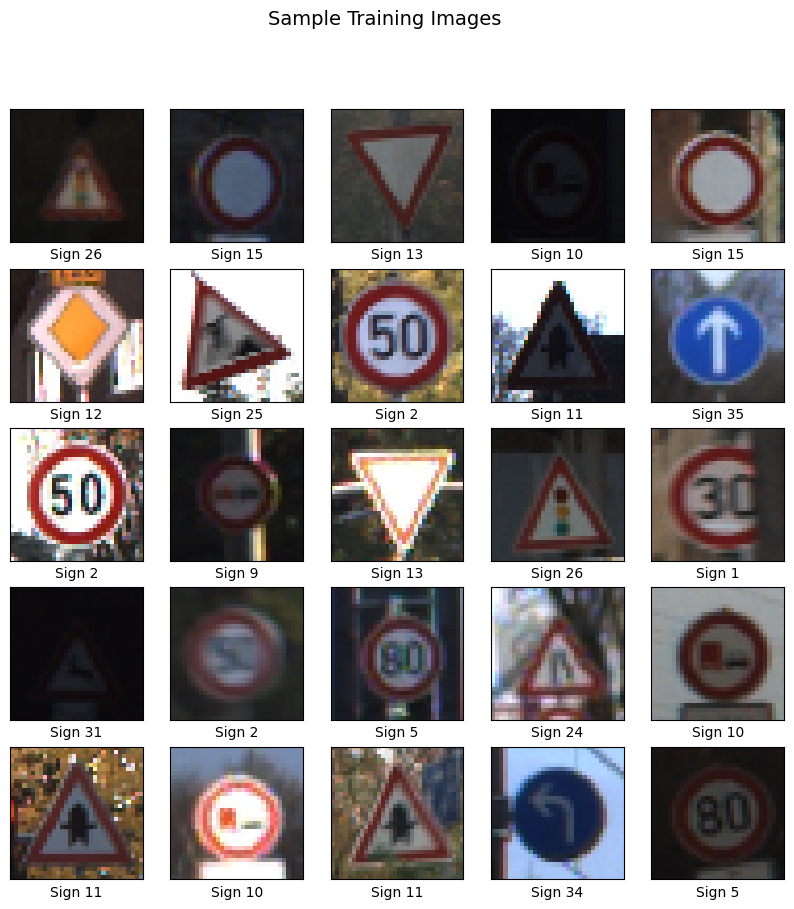

In [86]:
# ── CELL 6: Preview Some Training Images ────────────────────
class_names = [str(i) for i in range(NUM_CLASSES)]  # '0' to '42'

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(f"Sign {train_labels[i]}")
plt.suptitle("Sample Training Images", fontsize=14)
plt.show()

In [87]:
# ── CELL 7: Build the CNN Model ──────────────────────────────


model = models.Sequential()

model.add(layers.Conv2D(32,  (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64,  (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(NUM_CLASSES))   # 43 outputs — one per sign class

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,067 (1.38 MB)

 Trainable params: 361,067 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [88]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


In [89]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2    # 20% used for validation
)


Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 64s 63ms/step - accuracy: 0.7521 - loss: 0.9165 - val_accuracy: 0.9610 - val_loss: 0.1575
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 62ms/step - accuracy: 0.9676 - loss: 0.1303 - val_accuracy: 0.9727 - val_loss: 0.1048
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 83s 64ms/step - accuracy: 0.9812 - loss: 0.0698 - val_accuracy: 0.9714 - val_loss: 0.1082
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 64s 65ms/step - accuracy: 0.9875 - loss: 0.0455 - val_accuracy: 0.9825 - val_loss: 0.0691
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 59s 60ms/step - accuracy: 0.9910 - loss: 0.0304 - val_accuracy: 0.9842 - val_loss: 0.0627
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 59s 60ms/step - accuracy: 0.9919 - loss: 0.0279 - val_accuracy: 0.9899 - val_loss: 0.0405
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 57s 58ms/step - accuracy: 0.9943 - loss: 0.0187 - val_accuracy: 0.9906 - val_loss: 0.0428
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 57s 58ms/step - accuracy: 0.9938 - loss: 0.0190 - 

In [90]:
# ── CELL 3: Unzip Training Data (run once) ──────────────────
import zipfile

zip1 = '/content/drive/MyDrive/roadsigns/training1.zip'
zip2 = '/content/drive/MyDrive/roadsigns/training2.zip'

if not os.path.exists('/content/training_data'):
    with zipfile.ZipFile(zip1, 'r') as z:
        z.extractall('/content/training_data')
    with zipfile.ZipFile(zip2, 'r') as z:
        z.extractall('/content/training_data')
    print("Done unzipping!")
else:
    print("Already unzipped.")

Already unzipped.


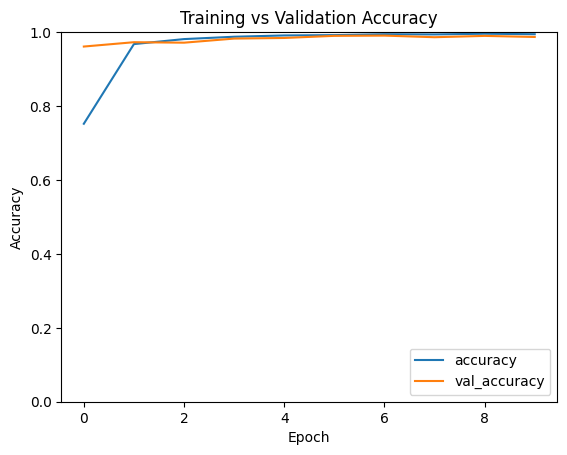

In [91]:
# ── CELL 10: Plot Accuracy ───────────────────────────────────
plt.plot(history.history['accuracy'],     label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')
plt.show()


In [92]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/roadsigns/holdout.zip', 'r') as z:
    z.extractall('/content/holdout_data')
    print("Done unzipping holdout!")

# Check what's inside
for root, dirs, files in os.walk('/content/holdout_data'):
    level = root.replace('/content/holdout_data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files[:3]:
        print(f'{indent}  {f}')

Done unzipping holdout!
holdout_data/
  holdout/
    06265.jpg
    05021.jpg
    10502.jpg


In [93]:
# ── CELL 11: Load Holdout Test Images ────────────────────────
TEST_DIR = '/content/holdout_data/holdout'

all_test_images = []
all_filenames   = []

for fname in sorted(os.listdir(TEST_DIR)):
    if fname.endswith('.jpg') or fname.endswith('.ppm'):
        img_path = os.path.join(TEST_DIR, fname)
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
        all_test_images.append(img_array)
        all_filenames.append(fname)

all_test_images = np.array(all_test_images)
all_preds = np.argmax(model.predict(all_test_images), axis=1)

submission = pd.DataFrame({'Filename': all_filenames, 'ClassId': all_preds})
submission.to_csv('predictions.csv', index=False)
print("Predictions saved!")
print(submission.head(10))

395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step
Predictions saved!
    Filename  ClassId
0  00000.jpg       16
1  00001.jpg        1
2  00002.jpg       38
3  00003.jpg       33
4  00004.jpg       11
5  00005.jpg       38
6  00006.jpg       18
7  00007.jpg       12
8  00008.jpg       25
9  00009.jpg       35


In [94]:
model.save('gehirnwagen_roadsign_model.h5')

import shutil
shutil.copy('gehirnwagen_roadsign_model.h5',
            '/content/drive/MyDrive/roadsigns/gehirnwagen_roadsign_model.h5')

print("Model saved!")

Model saved!


In [95]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/roadsigns/holdout.zip', 'r') as z:
    for name in z.namelist():
        print(name)

Streaming output truncated to the last 5000 lines.
holdout/07630.jpg
holdout/07631.jpg
holdout/07632.jpg
holdout/07633.jpg
holdout/07634.jpg
holdout/07635.jpg
holdout/07636.jpg
holdout/07637.jpg
holdout/07638.jpg
holdout/07639.jpg
holdout/07640.jpg
holdout/07641.jpg
holdout/07642.jpg
holdout/07643.jpg
holdout/07644.jpg
holdout/07645.jpg
holdout/07646.jpg
holdout/07647.jpg
holdout/07648.jpg
holdout/07649.jpg
holdout/07650.jpg
holdout/07651.jpg
holdout/07652.jpg
holdout/07653.jpg
holdout/07654.jpg
holdout/07655.jpg
holdout/07656.jpg
holdout/07657.jpg
holdout/07658.jpg
holdout/07659.jpg
holdout/07660.jpg
holdout/07661.jpg
holdout/07662.jpg
holdout/07663.jpg
holdout/07664.jpg
holdout/07665.jpg
holdout/07666.jpg
holdout/07667.jpg
holdout/07668.jpg
holdout/07669.jpg
holdout/07670.jpg
holdout/07671.jpg
holdout/07672.jpg
holdout/07673.jpg
holdout/07674.jpg
holdout/07675.jpg
holdout/07676.jpg
holdout/07677.jpg
holdout/07678.jpg
holdout/07679.jpg
holdout/07680.jpg
holdout/07681.jpg
holdout/07682

246/246 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step


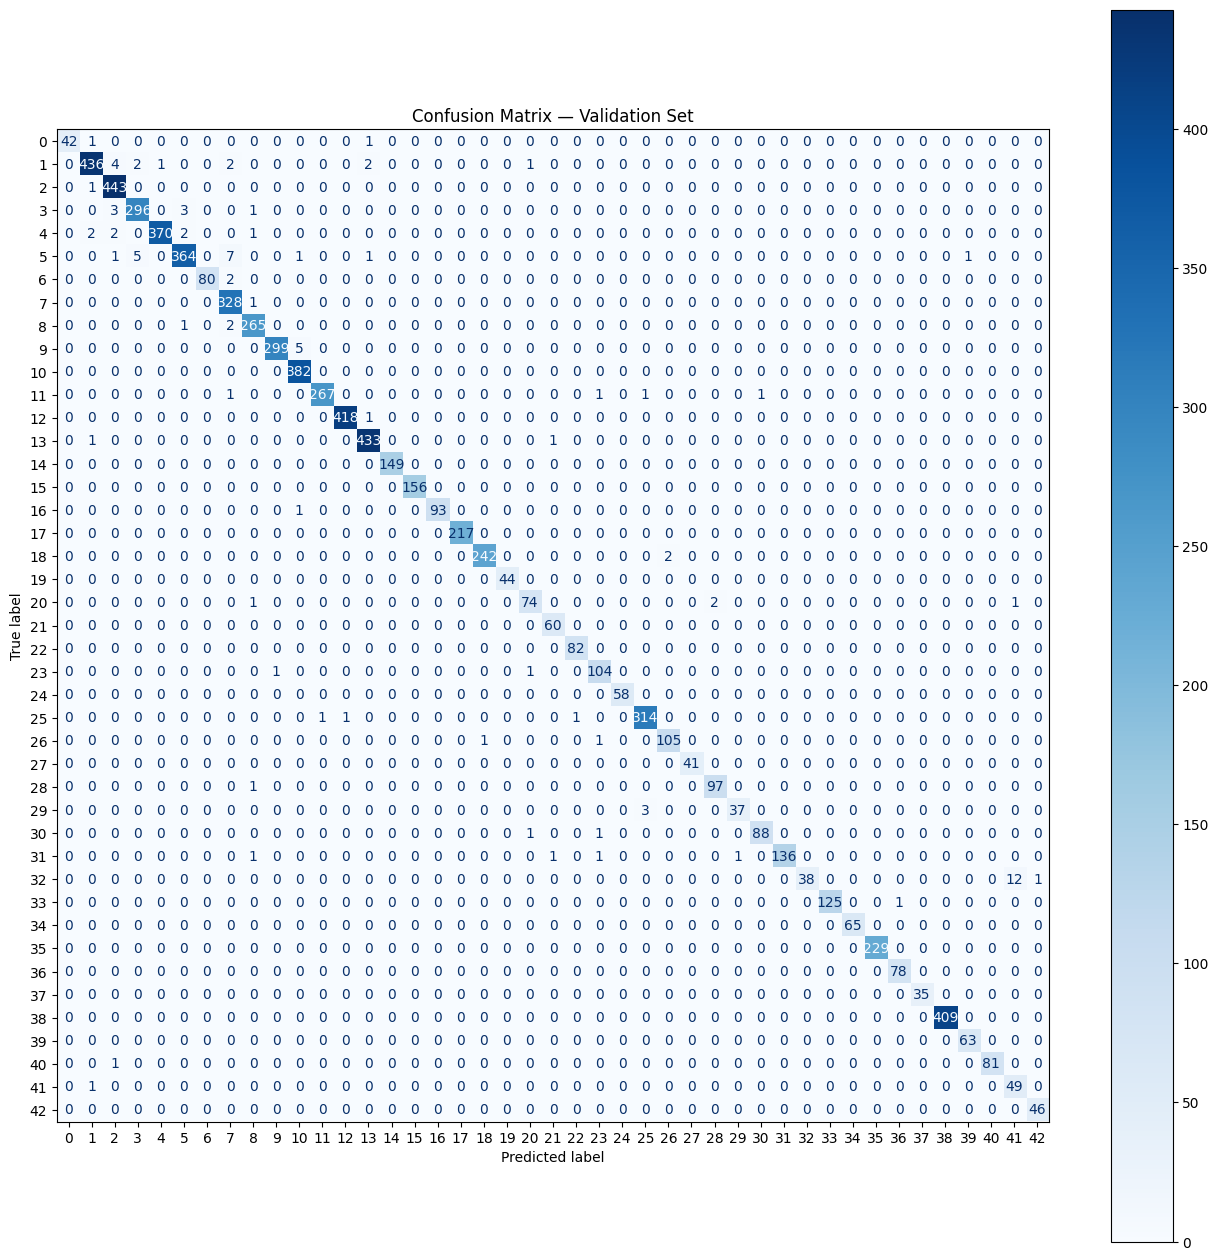

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        44
           1       0.99      0.97      0.98       448
           2       0.98      1.00      0.99       444
           3       0.98      0.98      0.98       303
           4       1.00      0.98      0.99       377
           5       0.98      0.96      0.97       380
           6       1.00      0.98      0.99        82
           7       0.96      1.00      0.98       329
           8       0.98      0.99      0.98       268
           9       1.00      0.98      0.99       304
          10       0.98      1.00      0.99       382
          11       1.00      0.99      0.99       271
          12       1.00      1.00      1.00       419
          13       0.99      1.00      0.99       435
          14       1.00      1.00      1.00       149
          15       1.00      1.00      1.00       156
          16       1.00      0.99      0.99        94
          17       1.00    

In [96]:
# Use validation data instead of partial test set
val_images = train_images[-7841:]   # last 20% = validation set
val_labels = train_labels[-7841:]

predictions_raw = model.predict(val_images)
predictions_new = np.argmax(predictions_raw, axis=1)

# Confusion Matrix
cm  = confusion_matrix(val_labels, predictions_new)
cmd = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(16, 16))
cmd.plot(ax=ax, cmap="Blues", values_format='.5g')
plt.title("Confusion Matrix — Validation Set")
plt.show()

# Classification Report
print(classification_report(val_labels, predictions_new))

In [99]:
import pandas as pd

url = 'https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout_answers.csv'
answers_df = pd.read_csv(url)
print(answers_df.head())
print(answers_df.columns.tolist())

    Filename  ClassId
0  00000.jpg       16
1  00001.jpg        1
2  00002.jpg       38
3  00003.jpg       33
4  00004.jpg       11
['Filename', 'ClassId']


In [100]:
TEST_DIR = '/content/holdout_data/holdout'

mini_images = []
mini_filenames = []

for fname in sorted(answers_df.iloc[:, 0]):  # first column = filenames
    img_path = os.path.join(TEST_DIR, fname)
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    mini_images.append(img_array)
    mini_filenames.append(fname)

mini_images = np.array(mini_images)
mini_preds = np.argmax(model.predict(mini_images), axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [101]:
from sklearn.metrics import classification_report, accuracy_score

true_labels = answers_df.iloc[:, 1].values  # second column = true class

accuracy = accuracy_score(true_labels, mini_preds)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(true_labels, mini_preds))

Accuracy: 0.9552
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         8
           3       1.00      0.90      0.95        10
           4       1.00      1.00      1.00         9
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8
           8       1.00      0.83      0.91         6
           9       1.00      1.00      1.00        10
          10       1.00      1.00      1.00        12
          11       1.00      1.00      1.00         8
          12       1.00      1.00      1.00         7
          13       1.00      1.00      1.00        10
          14       1.00      1.00      1.00         4
          15       0.67      1.00      0.80         2
          16       1.00      1.00      1.00         5
          17       1.00      1.00      1.00         7
          

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
